# 실습 3-2 : GBM, XGBoost, LightGBM, CatBoost

#### **<실습 내용>**

1. 분류 (Classification) - MachineFailure 데이터
- GBM, XGBoost, LightGBM, CatBoost 모델 학습 및 하이퍼 파라미터 최적화
- 모델 결과 비교 

2. 회귀 (Regression) - Concrete 데이터
- GBM, XGBoost, LightGBM, CatBoost 모델 학습 및 하이퍼 파라미터 최적화
- 모델 결과 비교 

## 분석 준비

### 주요 라이브러리 호출

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### 성능 평가 함수 정의

In [3]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))

# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

---

## 1. 분류 (Classification) - MachineFailure 데이터

In [7]:
MF_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7900 entries, 0 to 7899
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Temperature                   7900 non-null   int64 
 1   Humidity                      7900 non-null   int64 
 2   Operator                      7900 non-null   object
 3   Measure1                      7900 non-null   int64 
 4   Measure2                      7900 non-null   int64 
 5   Measure3                      7900 non-null   int64 
 6   Measure4                      7900 non-null   int64 
 7   Measure5                      7900 non-null   int64 
 8   Measure6                      7900 non-null   int64 
 9   Measure7                      7900 non-null   int64 
 10  Measure8                      7900 non-null   int64 
 11  Measure9                      7900 non-null   int64 
 12  Measure10                     7900 non-null   int64 
 13  Measure11         

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7900 entries, 0 to 7899
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Temperature                   7900 non-null   int64
 1   Humidity                      7900 non-null   int64
 2   Measure1                      7900 non-null   int64
 3   Measure4                      7900 non-null   int64
 4   Measure5                      7900 non-null   int64
 5   Measure6                      7900 non-null   int64
 6   Measure7                      7900 non-null   int64
 7   Measure8                      7900 non-null   int64
 8   Measure9                      7900 non-null   int64
 9   Measure10                     7900 non-null   int64
 10  Measure11                     7900 non-null   int64
 11  Measure12                     7900 non-null   int64
 12  Measure13                     7900 non-null   int64
 13  Measure14                     790

### 데이터 전처리

In [6]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-2_cls_data.csv"))

# 입출력 변수 분할 및 전처리
Y = MF_Data["Failure"]
X = MF_Data.drop(["Failure"], axis=1)

X["Measure2"] = X["Measure2"].astype("category")
X["Measure3"] = X["Measure3"].astype("category")
X = pd.get_dummies(X)
data_columns = X.columns

Y = Y.replace({"No": 0, "Yes": 1})

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)
print("학습 데이터 :", X_train.shape)
print("테스트 데이터 :", X_test.shape)

학습 데이터 : (5530, 31)
테스트 데이터 : (2370, 31)


C:\Users\Admin\AppData\Local\Temp\ipykernel_11876\4124609564.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = Y.replace({"No": 0, "Yes": 1})


---

### 1-1) GBM

> **GBM (Gradient Boosting Machine)** 은 이전 라운드의 베이스 모델이 잘못 예측한 **잔차(residual)** 를 다음 라운드의 베이스 모델이 학습하는 순차적 앙상블 기법임

In [8]:
GBM_cls = GradientBoostingClassifier()
GBM_cls.fit(X_train, Y_train)
GBM_cls_pred = GBM_cls.predict(X_test)
get_classscore(Y_test, GBM_cls_pred)

Accuracy  : 0.997
Precision : 0.944
Recall    : 0.773
F1-score  : 0.850


#### 변수 중요도 시각화

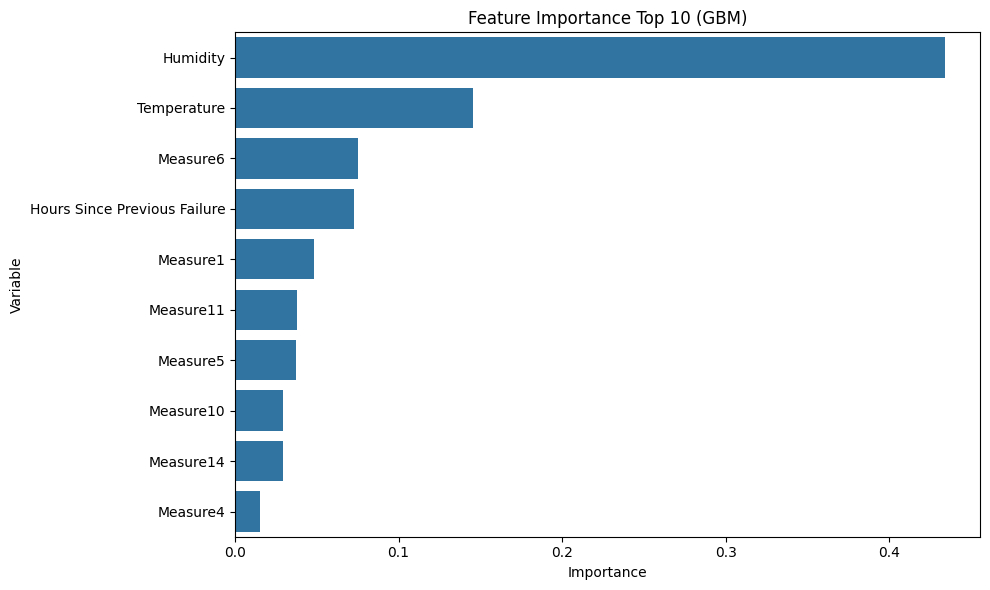

In [9]:
var_imp_gbm_cls = pd.DataFrame({"Variable": X_train.columns, "Importance": GBM_cls.feature_importances_})
imp_top10_gbm_cls = var_imp_gbm_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_gbm_cls)
plt.title("Feature Importance Top 10 (GBM)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> GBM의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | learning_rate | 0.1 | 이전 오차를 얼마나 반영할지 결정 |
> | subsample | 1.0 | 각 트리 학습 시 사용할 데이터 비율 |
> | validation_fraction | 0.1 | 조기 종료를 위한 검증 데이터 비율 |
> | n_iter_no_change | None | 성능 향상이 없을 경우 학습 중단 |
> | n_estimators | 100 | 생성할 트리의 개수 |
> | max_depth | 3 | 트리의 최대 깊이 |
> | max_leaf_nodes | None | 리프 노드의 최대 개수 |
> | min_samples_leaf | 1 | 리프 노드가 되기 위한 최소 샘플 수 |
> | min_samples_split | 2 | 노드를 분할하기 위한 최소 샘플 수 |

In [12]:
params_gbm_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_leaf": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_gbm_cls = GridSearchCV(
    GradientBoostingClassifier(random_state=0),
    param_grid=params_gbm_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_gbm_cls.fit(X_train, Y_train)

print("최적 파라미터:", grid_gbm_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_gbm_cls.best_score_)

KeyboardInterrupt: 

In [11]:
best_gbm_cls_pred = grid_gbm_cls.predict(X_test)
print("[GBM - 최적 모델]")
get_classscore(Y_test, best_gbm_cls_pred)

NotFittedError: This GridSearchCV instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

---

### 1-2) XGBoost

> **XGBoost**는 GBM에 **트리 규제항(Regularization)** 을 추가하여 과적합을 방지하는 모델임

In [11]:
XGB_cls = XGBClassifier()
XGB_cls.fit(X_train, Y_train)
XGB_cls_pred = XGB_cls.predict(X_test)
get_classscore(Y_test, XGB_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842


#### 변수 중요도 시각화

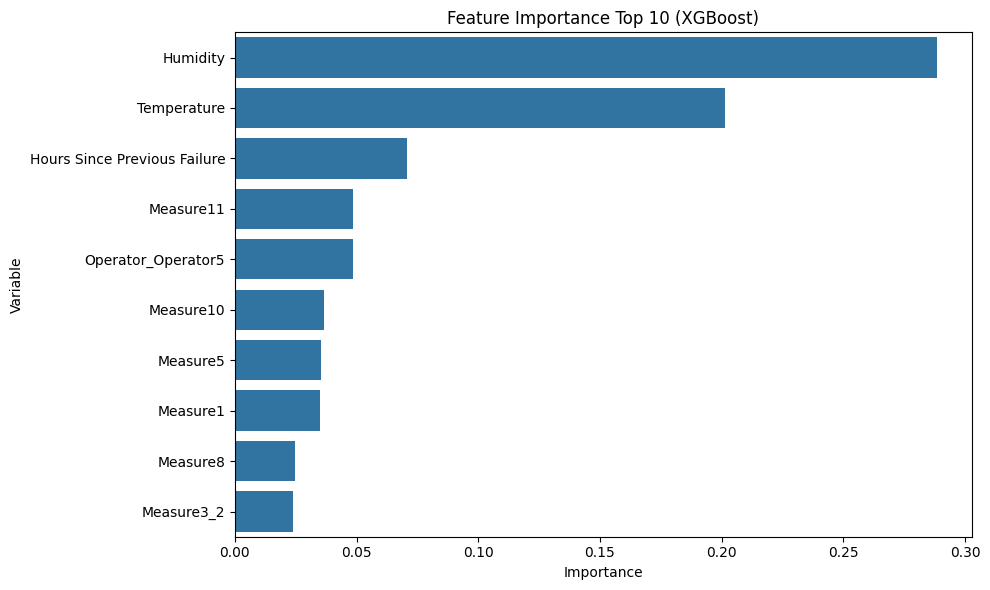

In [12]:
var_imp_xgb_cls = pd.DataFrame({"Variable": X_train.columns, "Importance": XGB_cls.feature_importances_})
imp_top10_xgb_cls = var_imp_xgb_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_xgb_cls)
plt.title("Feature Importance Top 10 (XGBoost)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> XGBoost의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | colsample_bytree | 1.0 | 각 트리 학습 시 사용할 변수 비율 |
> | gamma | 0.0 | 추가 분할을 수행할 최소 기준 값 (클수록 단순한 모델 생성) |
> | reg_lambda | 1.0 | 과적합 방지를 위한 정규화 강도 |
> | n_estimators | 100 | 생성할 트리의 개수 |
> | max_depth | 6 | 트리의 최대 깊이 |
> | learning_rate | 0.1 | 각 트리가 이전 오차를 얼마나 반영할지 결정 |

In [13]:
params_xgb_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "gamma": [0, 2],
    "reg_lambda": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_xgb_cls = GridSearchCV(
    XGBClassifier(random_state=0, eval_metric="logloss"),
    param_grid=params_xgb_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_xgb_cls.fit(X_train, Y_train)

print("최적 파라미터:", grid_xgb_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_xgb_cls.best_score_)

최적 파라미터: {'gamma': 2, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_lambda': 1, 'subsample': 1.0}
최적 F1-score (CV): 0.8473


In [14]:
best_xgb_cls_pred = grid_xgb_cls.predict(X_test)
print("[XGBoost - 최적 모델]")
get_classscore(Y_test, best_xgb_cls_pred)

[XGBoost - 최적 모델]
Accuracy  : 0.998
Precision : 1.000
Recall    : 0.773
F1-score  : 0.872


---

### 1-3) LightGBM

> **LightGBM**은 GBM의 학습 속도를 개선한 모델로, 다음 기술을 사용함
> - **GOSS** (Gradient-Based One Side Sampling): 잔차가 큰 데이터를 우선 학습하여 학습 데이터를 줄임
> - **Leaf-Wise Tree Growth**: 가장 큰 Loss를 가진 노드만 분할하여 트리 생성 속도를 높임
> - XGBoost 대비 최대 **38배 빠른 학습 속도**를 보이면서 비슷하거나 높은 정확도를 달성함

In [21]:
LGBM_cls = LGBMClassifier(verbose=-1)
LGBM_cls.fit(X_train, Y_train)
LGBM_cls_pred = LGBM_cls.predict(X_test)
get_classscore(Y_test, LGBM_cls_pred)

Accuracy  : 0.998
Precision : 1.000
Recall    : 0.773
F1-score  : 0.872


#### 변수 중요도 시각화

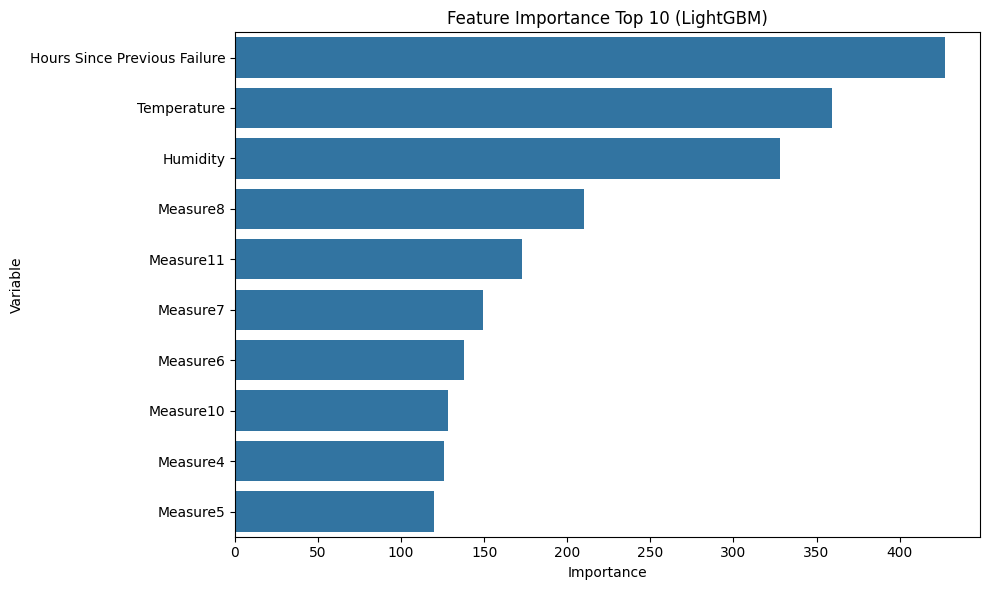

In [16]:
var_imp_lgbm_cls = pd.DataFrame({"Variable": X_train.columns, "Importance": LGBM_cls.feature_importances_})
imp_top10_lgbm_cls = var_imp_lgbm_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_lgbm_cls)
plt.title("Feature Importance Top 10 (LightGBM)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> LightGBM의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | num_leaves | 31 | 하나의 트리가 가질 수 있는 최대 리프 노드 수 |
> | min_child_samples | 20 | 리프 노드가 되기 위한 최소 샘플 수 (min_samples_leaf와 거의 동일) |
> | n_estimators | 100 | 생성할 트리의 개수 |
> | max_depth | 6 | 트리의 최대 깊이 |
> | learning_rate | 0.1 | 각 트리가 이전 오차를 얼마나 반영할지 결정 |
> | colsample_bytree | 1.0 | 각 트리 학습 시 사용할 변수 비율 |

In [25]:
params_lgbm_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "num_leaves": [15, 31],
    "min_child_samples": [20, 50],
    "subsample": [0.8, 1.0]
}

grid_lgbm_cls = GridSearchCV(
    LGBMClassifier(random_state=0, subsample_freq=1, verbose=-1),
    param_grid=params_lgbm_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_lgbm_cls.fit(X_train, Y_train)

print("최적 파라미터:", grid_lgbm_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_lgbm_cls.best_score_)

최적 파라미터: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 15, 'subsample': 0.8}
최적 F1-score (CV): 0.8344


In [26]:
best_lgbm_cls_pred = grid_lgbm_cls.predict(X_test)
print("[LightGBM - 최적 모델]")
get_classscore(Y_test, best_lgbm_cls_pred)

[LightGBM - 최적 모델]
Accuracy  : 0.997
Precision : 0.941
Recall    : 0.727
F1-score  : 0.821


---

### 1-4) CatBoost

> **CatBoost**는 범주형 변수가 많은 데이터에서 좋은 성능을 보이는 GBM 계열 모델임
> - 별도의 One-Hot Encoding 없이 범주형 변수를 직접 처리할 수 있음

In [27]:
# CatBoost 전용: One-hot 인코딩 전 원본 데이터 사용

X_cat = MF_Data.drop(["Failure"], axis=1)

cat_features = ["Operator", "Measure2", "Measure3"]
for col in cat_features:
    X_cat[col] = X_cat[col].astype("category")

Xc_train, Xc_test, Yc_train, Yc_test = train_test_split(
    X_cat, Y, test_size=0.3, random_state=0, stratify=Y
)
print("CatBoost 학습 데이터 :", Xc_train.shape)
print("CatBoost 테스트 데이터 :", Xc_test.shape)

CatBoost 학습 데이터 : (5530, 19)
CatBoost 테스트 데이터 : (2370, 19)


In [30]:
CAT_cls = CatBoostClassifier(verbose=0)
# 범주형 변수 목록을 명시해야 category dtype 컬럼을 처리할 수 있음
CAT_cls.fit(Xc_train, Yc_train, cat_features=cat_features)

CAT_cls_pred = CAT_cls.predict(Xc_test)
get_classscore(Yc_test, CAT_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842


#### 변수 중요도 시각화

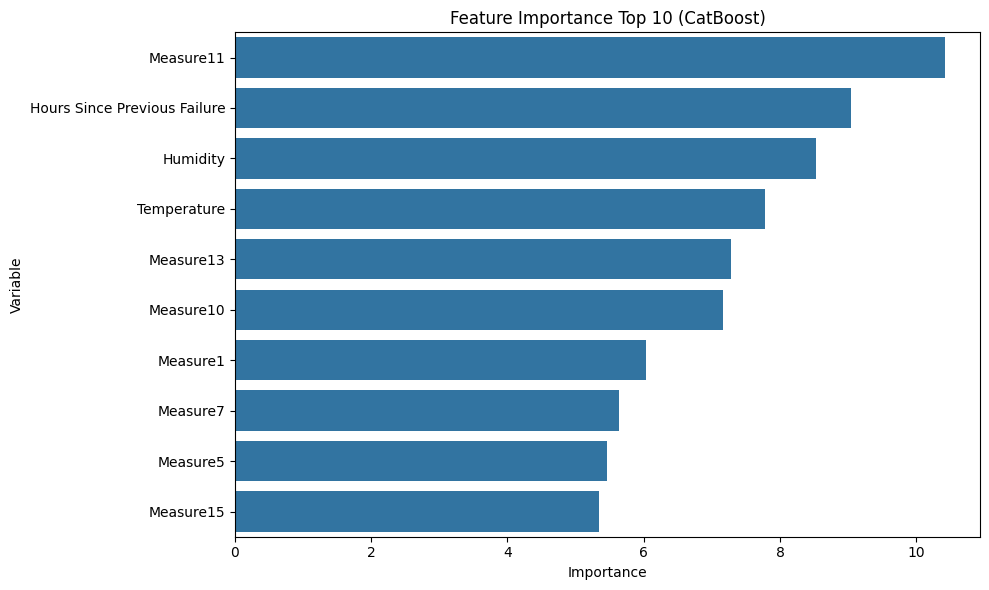

In [31]:
var_imp_cat_cls = pd.DataFrame({"Variable": Xc_train.columns, "Importance": CAT_cls.feature_importances_})
imp_top10_cat_cls = var_imp_cat_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_cat_cls)
plt.title("Feature Importance Top 10 (CatBoost)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> CatBoost의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | l2_leaf_reg | 3.0 | 과적합 방지를 위한 정규화 강도 |
> | random_strength | 1.0 | 트리 생성 시 랜덤성을 부여하는 정도 |
> | bagging_temperature | 1.0 | 데이터 샘플링 강도 |
> | border_count | 254 | 연속형 변수를 구간화하는 개수 |
> | iteration | 100 | 생성할 트리의 개수 |
> | depth | 6 | 트리의 최대 깊이 |
> | learning_rate | 0.1 | 각 트리가 이전 오차를 얼마나 반영할지 결정 |

In [32]:
params_cat_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "l2_leaf_reg": [1, 3, 5],
    "subsample": [0.8, 1.0]
}

grid_cat_cls = GridSearchCV(
    CatBoostClassifier(random_state=0, verbose=0, bootstrap_type="Bernoulli"),
    param_grid=params_cat_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_cat_cls.fit(Xc_train, Yc_train, cat_features=cat_features)

print("최적 파라미터:", grid_cat_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_cat_cls.best_score_)

최적 파라미터: {'l2_leaf_reg': 3, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
최적 F1-score (CV): 0.8515


In [33]:
best_cat_cls_pred = grid_cat_cls.predict(Xc_test)
print("[CatBoost - 최적 모델]")
get_classscore(Yc_test, best_cat_cls_pred)

[CatBoost - 최적 모델]
Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842


---

## 2. 회귀 (Regression) - Concrete 데이터

> 분류에서 다룬 GBM 계열 모델들은 **회귀** 문제에도 동일하게 적용할 수 있음
> - Classifier → Regressor로 변경하고, 평가 지표를 MSE, R-squared 등으로 변경함
> - 각 모델의 하이퍼 파라미터는 분류와 동일하게 적용됨

### 데이터 전처리

In [34]:
Concrete = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-2_reg_data.csv"))

Y_reg = Concrete["Concrete_compressive_strength"]
X_reg = Concrete.drop(["Concrete_compressive_strength"], axis=1)

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 :", X_train_reg.shape)
print("테스트 데이터 :", X_test_reg.shape)

학습 데이터 : (721, 8)
테스트 데이터 : (309, 8)


---

### 2-1) GBM

In [35]:
GBM_reg = GradientBoostingRegressor()
GBM_reg.fit(X_train_reg, Y_train_reg)
GBM_reg_pred = GBM_reg.predict(X_test_reg)
get_regscore(Y_test_reg, GBM_reg_pred)

MSE       : 26.150
RMSE      : 5.114
MAE       : 3.833
R-squared : 0.898


#### 변수 중요도 시각화

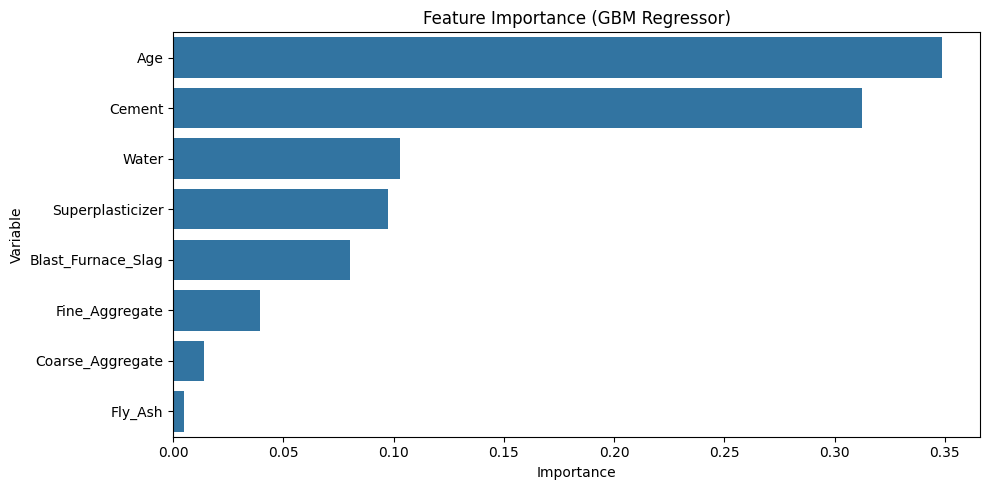

In [36]:
var_imp_gbm_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": GBM_reg.feature_importances_})
var_imp_gbm_reg = var_imp_gbm_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_gbm_reg)
plt.title("Feature Importance (GBM Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [37]:
params_gbm_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_leaf": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_gbm_reg = GridSearchCV(
    GradientBoostingRegressor(random_state=0),
    param_grid=params_gbm_reg, cv=3, scoring="r2", n_jobs=-1
)
grid_gbm_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_gbm_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_gbm_reg.best_score_)

최적 파라미터: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 300, 'subsample': 0.8}
최적 R-squared (CV): 0.9140


In [38]:
best_gbm_reg_pred = grid_gbm_reg.predict(X_test_reg)
print("[GBM - 최적 모델]")
get_regscore(Y_test_reg, best_gbm_reg_pred)

[GBM - 최적 모델]
MSE       : 19.442
RMSE      : 4.409
MAE       : 3.069
R-squared : 0.924


---

### 2-2) XGBoost

In [39]:
XGB_reg = XGBRegressor()
XGB_reg.fit(X_train_reg, Y_train_reg)
XGB_reg_pred = XGB_reg.predict(X_test_reg)
get_regscore(Y_test_reg, XGB_reg_pred)

MSE       : 21.905
RMSE      : 4.680
MAE       : 3.158
R-squared : 0.915


#### 변수 중요도 시각화

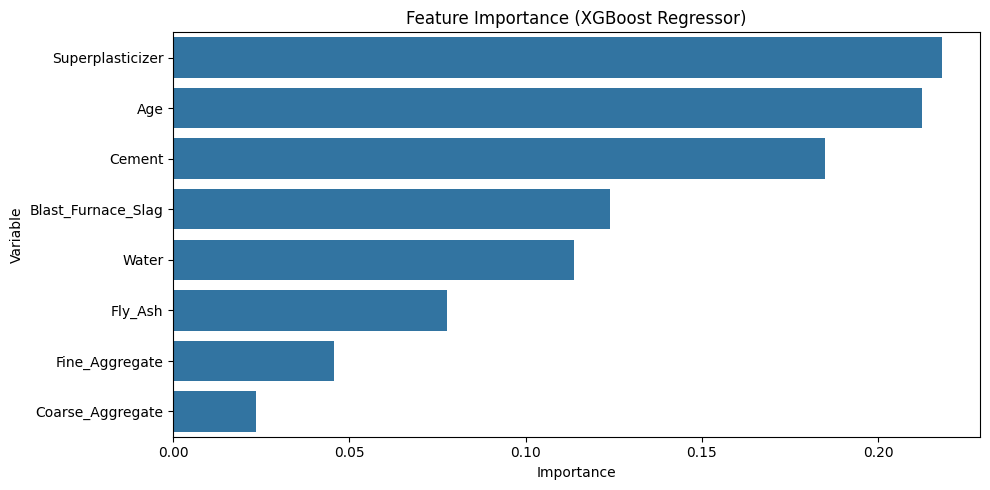

In [40]:
var_imp_xgb_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": XGB_reg.feature_importances_})
var_imp_xgb_reg = var_imp_xgb_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_xgb_reg)
plt.title("Feature Importance (XGBoost Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [41]:
params_xgb_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "gamma": [0, 2],
    "reg_lambda": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_xgb_reg = GridSearchCV(
    XGBRegressor(random_state=0),
    param_grid=params_xgb_reg, cv=3, scoring="r2", n_jobs=-1
)
grid_xgb_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_xgb_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_xgb_reg.best_score_)

최적 파라미터: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_lambda': 5, 'subsample': 0.8}
최적 R-squared (CV): 0.9136


In [42]:
best_xgb_reg_pred = grid_xgb_reg.predict(X_test_reg)
print("[XGBoost - 최적 모델]")
get_regscore(Y_test_reg, best_xgb_reg_pred)

[XGBoost - 최적 모델]
MSE       : 21.153
RMSE      : 4.599
MAE       : 3.243
R-squared : 0.918


---

### 2-3) LightGBM

In [43]:
LGBM_reg = LGBMRegressor(verbose=-1)
LGBM_reg.fit(X_train_reg, Y_train_reg)
LGBM_reg_pred = LGBM_reg.predict(X_test_reg)
get_regscore(Y_test_reg, LGBM_reg_pred)

MSE       : 21.353
RMSE      : 4.621
MAE       : 3.244
R-squared : 0.917


#### 변수 중요도 시각화

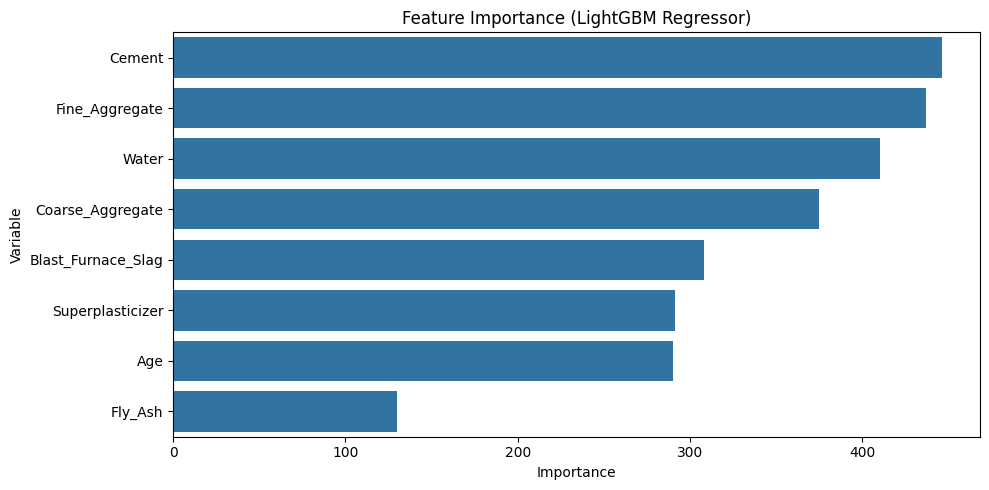

In [44]:
var_imp_lgbm_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": LGBM_reg.feature_importances_})
var_imp_lgbm_reg = var_imp_lgbm_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_lgbm_reg)
plt.title("Feature Importance (LightGBM Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [45]:
params_lgbm_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "num_leaves": [15, 31],
    "min_child_samples": [20, 50],
    "subsample": [0.8, 1.0]
}

grid_lgbm_reg = GridSearchCV(
    LGBMRegressor(random_state=0, verbose=-1),
    param_grid=params_lgbm_reg, cv=3, scoring="r2", n_jobs=-1
)
grid_lgbm_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_lgbm_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_lgbm_reg.best_score_)

최적 파라미터: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 15, 'subsample': 0.8}
최적 R-squared (CV): 0.9119


In [46]:
best_lgbm_reg_pred = grid_lgbm_reg.predict(X_test_reg)
print("[LightGBM - 최적 모델]")
get_regscore(Y_test_reg, best_lgbm_reg_pred)

[LightGBM - 최적 모델]
MSE       : 20.376
RMSE      : 4.514
MAE       : 3.080
R-squared : 0.921


---

### 2-4) CatBoost

In [53]:
CAT_reg = CatBoostRegressor(verbose=0)
# 해당 데이터셋에는 범주형이 없어서 따로 cat_features를 지정하지 않아도 동작 가능
CAT_reg.fit(X_train_reg, Y_train_reg)
CAT_reg_pred = CAT_reg.predict(X_test_reg)
get_regscore(Y_test_reg, CAT_reg_pred)

MSE       : 17.915
RMSE      : 4.233
MAE       : 2.778
R-squared : 0.930


#### 변수 중요도 시각화

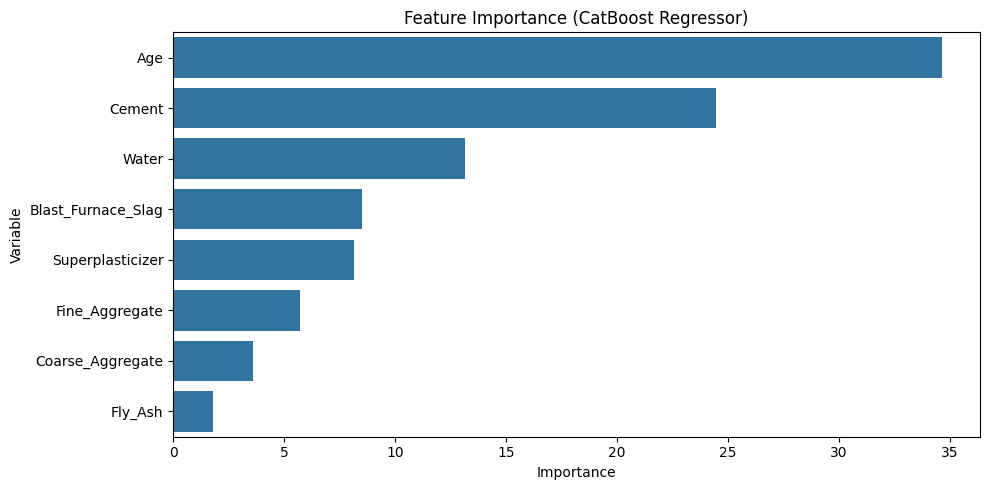

In [54]:
var_imp_cat_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": CAT_reg.feature_importances_})
var_imp_cat_reg = var_imp_cat_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_cat_reg)
plt.title("Feature Importance (CatBoost Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [49]:
params_cat_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "l2_leaf_reg": [1, 3, 5]
}

grid_cat_reg = GridSearchCV(
    CatBoostRegressor(random_state=0, verbose=0),
    param_grid=params_cat_reg, cv=3, scoring="r2"
)
grid_cat_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_cat_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_cat_reg.best_score_)

최적 파라미터: {'l2_leaf_reg': 3, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
최적 R-squared (CV): 0.9242


In [50]:
best_cat_reg_pred = grid_cat_reg.predict(X_test_reg)
print("[CatBoost - 최적 모델]")
get_regscore(Y_test_reg, best_cat_reg_pred)

[CatBoost - 최적 모델]
MSE       : 20.723
RMSE      : 4.552
MAE       : 3.117
R-squared : 0.919


---

In [ ]:
best_models_cls = {
    "GBM": best_gbm_cls_pred,
    "XGBoost": best_xgb_cls_pred,
    "LightGBM": best_lgbm_cls_pred,
    "CatBoost": best_cat_cls_pred
}

best_results_cls = []
for name, pred in best_models_cls.items():
    true = Yc_test if name == "CatBoost" else Y_test
    best_results_cls.append({
        "Model": name,
        "Accuracy": round(accuracy_score(true, pred), 3),
        "Precision": round(precision_score(true, pred), 3),
        "Recall": round(recall_score(true, pred), 3),
        "F1-score": round(f1_score(true, pred), 3)
    })

pd.DataFrame(best_results_cls)

,Model,Accuracy,Precision,Recall,F1-score
0,GBM,0.997,0.944,0.773,0.850
1,XGBoost,0.998,1.000,0.773,0.872
2,LightGBM,0.997,0.941,0.727,0.821
3,CatBoost,0.997,1.000,0.727,0.842


In [52]:
best_models_reg = {
    "GBM": best_gbm_reg_pred,
    "XGBoost": best_xgb_reg_pred,
    "LightGBM": best_lgbm_reg_pred,
    "CatBoost": best_cat_reg_pred
}

best_results_reg = []
for name, pred in best_models_reg.items():
    best_results_reg.append({
        "Model": name,
        "RMSE": round(np.sqrt(mean_squared_error(Y_test_reg, pred)), 3),
        "MAE": round(mean_absolute_error(Y_test_reg, pred), 3),
        "R-squared": round(r2_score(Y_test_reg, pred), 3)
    })

pd.DataFrame(best_results_reg)

,Model,RMSE,MAE,R-squared
0,GBM,4.409,3.069,0.924
1,XGBoost,4.599,3.243,0.918
2,LightGBM,4.514,3.080,0.921
3,CatBoost,4.552,3.117,0.919


---

## 3. Vibe Coding 실습

**[과제 1]** 지수는 LightGBM이 XGBoost보다 빠르게 학습된다는 설명을 들었지만, 실제로 얼마나 차이가 나는지 궁금했습니다. AI와 상의하여 동일한 데이터셋(회귀 또는 분류)으로 XGBoost와 LightGBM을 학습시키고 학습 시간과 예측 성능을 비교해 보세요.

[프롬프트]
동일한 데이터셋으로 XGBoost와 LightGBM을 학습시키고 둘의 학습 시간과 예측 성능을 비교해보고 싶어
1. 먼저 XGBoost 학습하고 학습 시간과 예측 성능을 비교하는 코드를 짜줘
2. LightGBM 학습하고 학습 시간과 예측 성능을 비교하는 코드를 짜줘
3. XGBoost와 LightGBM 학습시간, 예측 성능 비교해줘

단계별로 진행하고 단계가 끝난 다음에 결과를 보여줘 그다음에 내가 ok하면 그 다음으로 진행해줘

In [11]:
import time
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1단계: XGBoost 학습 + 시간 측정
xgb_model = XGBClassifier(random_state=0, eval_metric="logloss")

start = time.time()
xgb_model.fit(X_train, Y_train)
xgb_train_time = time.time() - start

# 예측 및 성능 평가
xgb_pred = xgb_model.predict(X_test)

print("=" * 50)
print("[1단계] XGBoost 결과")
print("=" * 50)
print(f"학습 시간: {xgb_train_time:.3f} sec")
print("-" * 50)
print("테스트 성능:")
get_classscore(Y_test, xgb_pred)

[1단계] XGBoost 결과
학습 시간: 0.167 sec
--------------------------------------------------
테스트 성능:
Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842


In [9]:
import time
from lightgbm import LGBMClassifier

# 2단계: LightGBM 학습 + 시간 측정
lgbm_model = LGBMClassifier(random_state=0, verbose=-1)

start = time.time()
lgbm_model.fit(X_train, Y_train)
lgbm_train_time = time.time() - start

# 예측 및 성능 평가
lgbm_pred = lgbm_model.predict(X_test)

print("=" * 50)
print("[2단계] LightGBM 결과")
print("=" * 50)
print(f"학습 시간: {lgbm_train_time:.3f} sec")
print("-" * 50)
print("테스트 성능:")
get_classscore(Y_test, lgbm_pred)

[2단계] LightGBM 결과
학습 시간: 5.571 sec
--------------------------------------------------
테스트 성능:
Accuracy  : 0.998
Precision : 1.000
Recall    : 0.773
F1-score  : 0.872


[3단계] XGBoost vs LightGBM 비교


,Model,Train Time (sec),Accuracy,Precision,Recall,F1-score
0,XGBoost,0.167,0.997,1.0,0.727,0.842
1,LightGBM,5.571,0.998,1.0,0.773,0.872


C:\Users\Admin\AppData\Local\Temp\ipykernel_11876\3141185934.py:54: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_11876\3141185934.py:54: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_11876\3141185934.py:54: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_11876\3141185934.py:54: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_11876\3141185934.py:54: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_11876\3141185934.py:54: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from 

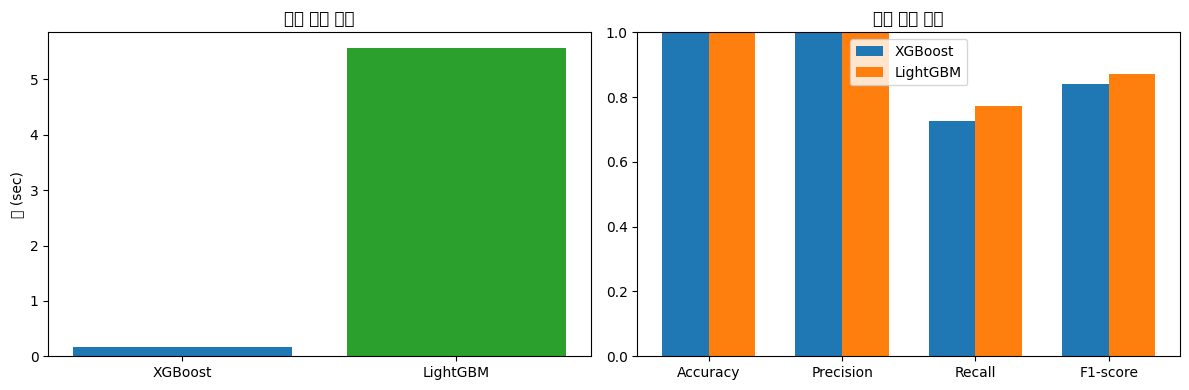


요약:
- 더 빠른 모델: XGBoost (약 33.3배 차이)
- F1-score 기준 더 좋은 모델: LightGBM


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 3단계: 학습 시간 + 예측 성능 비교
compare_df = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Train Time (sec)": [xgb_train_time, lgbm_train_time],
    "Accuracy": [
        accuracy_score(Y_test, xgb_pred),
        accuracy_score(Y_test, lgbm_pred)
    ],
    "Precision": [
        precision_score(Y_test, xgb_pred),
        precision_score(Y_test, lgbm_pred)
    ],
    "Recall": [
        recall_score(Y_test, xgb_pred),
        recall_score(Y_test, lgbm_pred)
    ],
    "F1-score": [
        f1_score(Y_test, xgb_pred),
        f1_score(Y_test, lgbm_pred)
    ]
})

# 보기 좋게 반올림
compare_df[["Train Time (sec)", "Accuracy", "Precision", "Recall", "F1-score"]] = \
    compare_df[["Train Time (sec)", "Accuracy", "Precision", "Recall", "F1-score"]].round(3)

print("=" * 50)
print("[3단계] XGBoost vs LightGBM 비교")
print("=" * 50)
display(compare_df)

# 학습 시간 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(compare_df["Model"], compare_df["Train Time (sec)"], color=["#1f77b4", "#2ca02c"])
axes[0].set_title("학습 시간 비교")
axes[0].set_ylabel("초 (sec)")

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(metrics))
width = 0.35
axes[1].bar([i - width/2 for i in x], compare_df.loc[0, metrics], width, label="XGBoost")
axes[1].bar([i + width/2 for i in x], compare_df.loc[1, metrics], width, label="LightGBM")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1)
axes[1].set_title("예측 성능 비교")
axes[1].legend()

plt.tight_layout()
plt.show()

# 요약 해석
faster = "LightGBM" if lgbm_train_time < xgb_train_time else "XGBoost"
speed_ratio = max(xgb_train_time, lgbm_train_time) / min(xgb_train_time, lgbm_train_time)
better_f1 = "LightGBM" if f1_score(Y_test, lgbm_pred) > f1_score(Y_test, xgb_pred) else "XGBoost"

print(f"\n요약:")
print(f"- 더 빠른 모델: {faster} (약 {speed_ratio:.1f}배 차이)")
print(f"- F1-score 기준 더 좋은 모델: {better_f1}")

**[과제 2]** 지수는 GBM, XGBoost, LightGBM, CatBoost가 같은 데이터를 학습했지만, 각 모델이 중요하게 판단하는 변수는 다를 수 있다고 생각했습니다. AI와 함께 회귀 또는 분류 문제에서 네 모델의 변수 중요도를 한눈에 비교할 수 있는 시각화 방법을 상의하고, 실제로 비교하여 모델 간 중요도 순위가 얼마나 일치하는지 확인해 보세요.

GBM, XGBoost, LightGBM, CatBoost 모두 트리모델이다보니 변수 중요도를 뽑을 수 있잖아?
4가지 모델이 모두 중요하다고 판단하는 변수가 비슷한지가 궁금해.

시각화 해서도 보고 싶고
4가지 모델 모두 일치하는 것, 3가지 모델 일치하는 것 이런 느낌으로도 출력해 보고 싶어

**[과제 3]** 지수는 여러 머신러닝 모델의 예측 결과를 결합하는 Stacking Ensemble이라는 방법을 알게 되었고, Stacking 모델이 단일 앙상블 모델보다 항상 더 좋은 성능을 보이는지 궁금해졌습니다. AI와 상의하여 결합할 모델들을 선택해 Stacking 모델을 구축해 보세요. 이후 Stacking 모델과 각 단일 앙상블 모델의 성능을 비교해 보세요.

Stacking Ensemble이라는 방법이 있다고 들었어 해당 Ensemble을 잘 몰라서 Stacking Ensemble에 대해서 먼저 설명해줘
1. 그리고 어떤 모델을 결합해야하는지 알려주고 나랑 결합할 모델 선택을 해줘
2. 1번에서 모델 선택이 끝나면 Stacking 모델 코드 짜는 프로세스를 선생님처럼 쉽게 설명해줘
3. 단일 앙상블 모델이랑 Stacking 모델이랑 비교하는 코드 짜줘

In [13]:
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# ===== Step 1: Base Model 정의 =====
base_models = [
    ("gbm", GradientBoostingClassifier(random_state=0)),
    ("xgb", XGBClassifier(random_state=0, eval_metric="logloss")),
    ("lgbm", LGBMClassifier(random_state=0, verbose=-1))
]

# ===== Step 2: Meta Model 정의 =====
meta_model = LogisticRegression(random_state=0, max_iter=1000)

# ===== Step 3: StackingClassifier 생성 =====
stacking_clf = StackingClassifier(
    estimators=base_models,      # 1층 모델들
    final_estimator=meta_model,  # 2층 메타 모델
    cv=5,                        # 1층 예측 생성 시 5-fold CV (과적합 방지)
    n_jobs=-1
)

# ===== Step 4: 학습 & 예측 =====
stacking_clf.fit(X_train, Y_train)
stacking_pred = stacking_clf.predict(X_test)

print("=" * 50)
print("[Stacking 모델] 테스트 성능")
print("=" * 50)
get_classscore(Y_test, stacking_pred)

[Stacking 모델] 테스트 성능
Accuracy  : 0.998
Precision : 1.000
Recall    : 0.773
F1-score  : 0.872


In [14]:
# 단일 모델들 (기본값, 빠른 비교용)
single_models = {
    "GBM": GradientBoostingClassifier(random_state=0),
    "XGBoost": XGBClassifier(random_state=0, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=0, verbose=-1)
}

results = []

# 1) 단일 모델 성능
for name, model in single_models.items():
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(Y_test, pred), 3),
        "Precision": round(precision_score(Y_test, pred), 3),
        "Recall": round(recall_score(Y_test, pred), 3),
        "F1-score": round(f1_score(Y_test, pred), 3)
    })

# 2) Stacking 성능
results.append({
    "Model": "Stacking",
    "Accuracy": round(accuracy_score(Y_test, stacking_pred), 3),
    "Precision": round(precision_score(Y_test, stacking_pred), 3),
    "Recall": round(recall_score(Y_test, stacking_pred), 3),
    "F1-score": round(f1_score(Y_test, stacking_pred), 3)
})

compare_stacking = pd.DataFrame(results)
print("\n" + "=" * 50)
print("단일 모델 vs Stacking 비교")
print("=" * 50)
display(compare_stacking)


단일 모델 vs Stacking 비교


,Model,Accuracy,Precision,Recall,F1-score
0,GBM,0.997,0.944,0.773,0.850
1,XGBoost,0.997,1.000,0.727,0.842
2,LightGBM,0.998,1.000,0.773,0.872
3,Stacking,0.998,1.000,0.773,0.872
